In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import sqlite3


In [19]:
df = pd.read_csv("../data/raw/detalle_agricola_municipal.csv")
df.head()

,Año,Departamento,Municipio,Producto,Área Cosechada,Área Sembrada,Producción,Rendimiento,Ciclo
0,2020,ANTIOQUIA,ABEJORRAL,AGUACATE HASS,"707,00","857,00","13.433,00","19,00",PERMANENTE
1,2022,ANTIOQUIA,ABEJORRAL,AGUACATE HASS,"3.857,00","4.307,00","73.283,00","19,00",PERMANENTE
2,2024,ANTIOQUIA,ABEJORRAL,AGUACATE HASS,"3.357,00","3.857,00","63.783,00","19,00",PERMANENTE
3,2021,ANTIOQUIA,ABEJORRAL,AGUACATE HASS,"707,00","1.007,00","13.433,00","19,00",PERMANENTE
4,2021,ANTIOQUIA,ABRIAQUI,AGUACATE HASS,"148,00","235,00","740,00","5,00",PERMANENTE


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Año             253 non-null    int64 
 1   Departamento    253 non-null    object
 2   Municipio       253 non-null    object
 3   Producto        253 non-null    object
 4   Área Cosechada  253 non-null    object
 5   Área Sembrada   253 non-null    object
 6   Producción      253 non-null    object
 7   Rendimiento     253 non-null    object
 8   Ciclo           253 non-null    object
dtypes: int64(1), object(8)
memory usage: 17.9+ KB


In [21]:
df.columns

Index(['Año', 'Departamento', 'Municipio', 'Producto', 'Área Cosechada',
       'Área Sembrada', 'Producción', 'Rendimiento', 'Ciclo'],
      dtype='object')

In [22]:
df.shape

(253, 9)

In [24]:
cols = ["Producción", "Área Cosechada", "Área Sembrada", "Rendimiento"]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('"', '', regex=False)
        .str.replace('.', '', regex=False)   # quita separador de miles
        .str.replace(',', '.', regex=False)  # convierte decimal
        .str.strip()
        .replace('', None)
        .astype(float)
    )

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Año             253 non-null    int64  
 1   Departamento    253 non-null    object 
 2   Municipio       253 non-null    object 
 3   Producto        253 non-null    object 
 4   Área Cosechada  253 non-null    float64
 5   Área Sembrada   253 non-null    float64
 6   Producción      253 non-null    float64
 7   Rendimiento     253 non-null    float64
 8   Ciclo           253 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 17.9+ KB


In [26]:
top_municipios = (
    df.groupby("Municipio")["Producción"]
    .sum()
    .sort_values(ascending=False)
)

top_municipios.head(10)

Municipio
URRAO          293851.80
SONSON         219800.00
ABEJORRAL      163932.00
JERICO          71362.00
RETIRO          48341.32
SAN VICENTE     35795.56
PEÑOL           29382.60
LA CEJA         24207.14
LA UNION        11895.53
MARINILLA       11855.60
Name: Producción, dtype: float64

<Axes: xlabel='Municipio'>

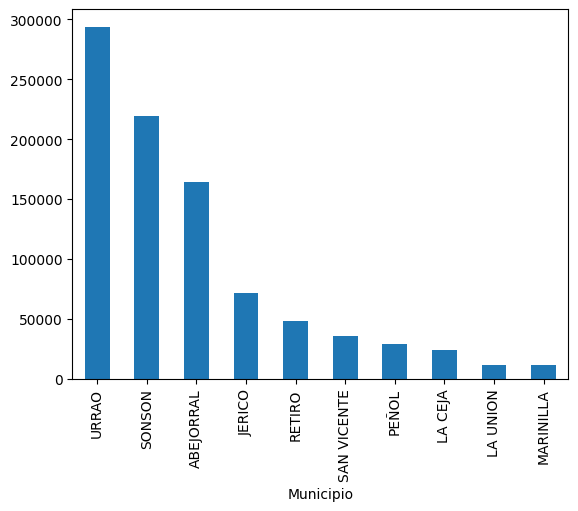

In [27]:
top_municipios.head(10).plot(kind="bar")

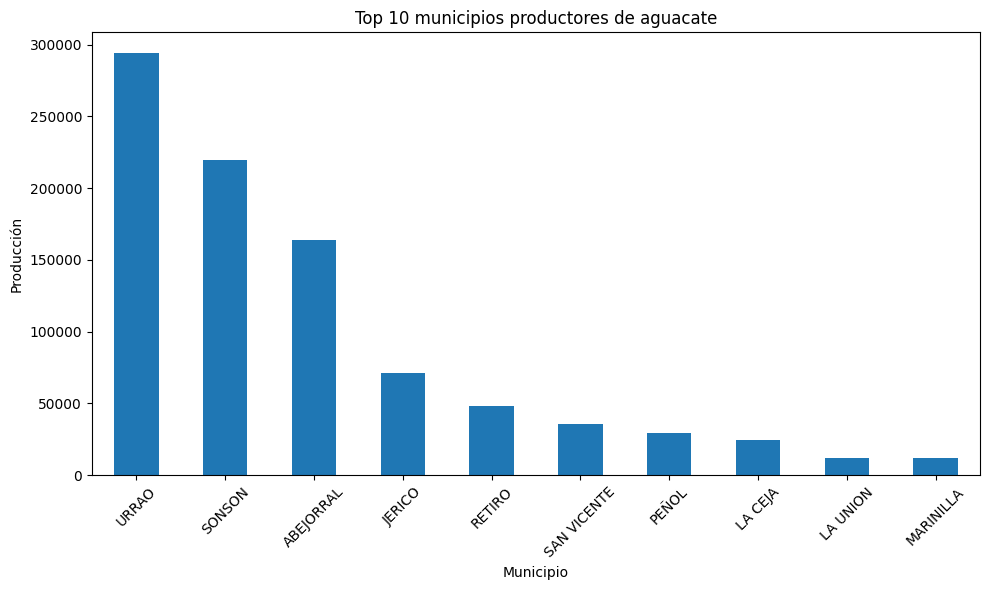

In [29]:
top_municipios.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 municipios productores de aguacate")
plt.xlabel("Municipio")
plt.ylabel("Producción")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [30]:
top_rendimiento = (
    df.groupby("Municipio")["Rendimiento"]
    .mean()
    .sort_values(ascending=False)
)

top_rendimiento.head(10)

Municipio
CARAMANTA            20.00
RETIRO               20.00
ABEJORRAL            19.00
LA UNION             18.20
CARMEN DE VIBORAL    18.00
YARUMAL              16.20
SALGAR               14.20
SONSON               14.00
URRAO                13.74
JARDIN               13.20
Name: Rendimiento, dtype: float64

In [31]:
print("Top Producción")
print(top_municipios.head(10))

print("\nTop Rendimiento")
print(top_rendimiento.head(10))

Top Producción
Municipio
URRAO          293851.80
SONSON         219800.00
ABEJORRAL      163932.00
JERICO          71362.00
RETIRO          48341.32
SAN VICENTE     35795.56
PEÑOL           29382.60
LA CEJA         24207.14
LA UNION        11895.53
MARINILLA       11855.60
Name: Producción, dtype: float64

Top Rendimiento
Municipio
CARAMANTA            20.00
RETIRO               20.00
ABEJORRAL            19.00
LA UNION             18.20
CARMEN DE VIBORAL    18.00
YARUMAL              16.20
SALGAR               14.20
SONSON               14.00
URRAO                13.74
JARDIN               13.20
Name: Rendimiento, dtype: float64


In [32]:
correlacion = df[["Producción", "Área Cosechada"]].corr()

print(correlacion)

                Producción  Área Cosechada
Producción        1.000000        0.985202
Área Cosechada    0.985202        1.000000


In [33]:
corr_rend = df[["Producción", "Rendimiento"]].corr()

print(corr_rend)

             Producción  Rendimiento
Producción     1.000000     0.346711
Rendimiento    0.346711     1.000000


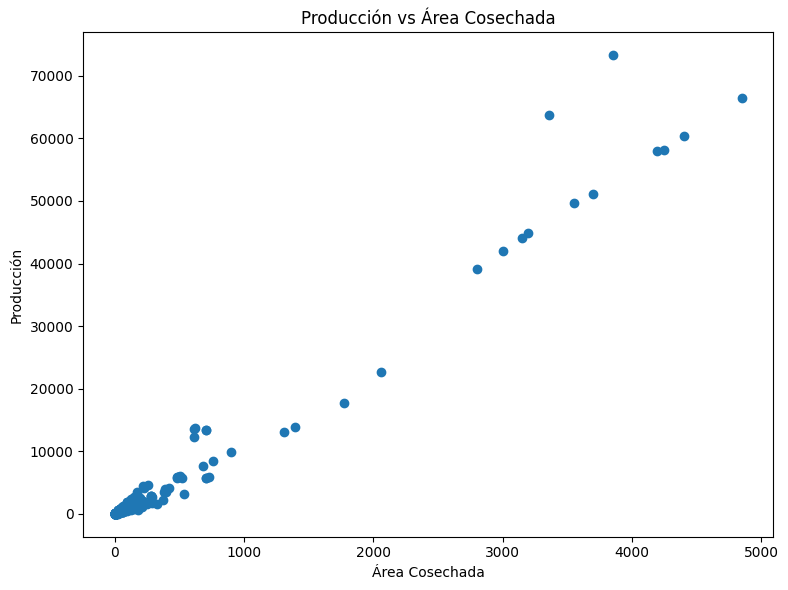

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Área Cosechada"],
    df["Producción"]
)

plt.title("Producción vs Área Cosechada")
plt.xlabel("Área Cosechada")
plt.ylabel("Producción")

plt.tight_layout()
plt.show()

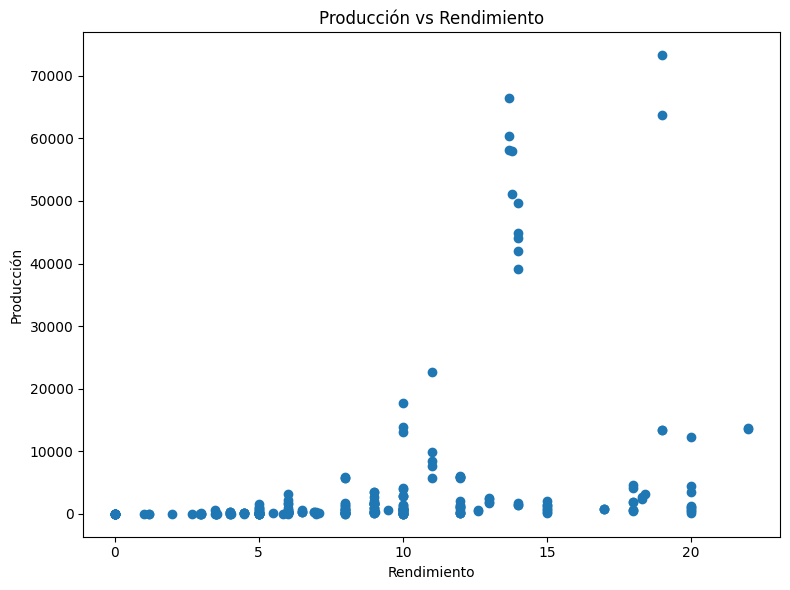

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Rendimiento"],
    df["Producción"]
)

plt.title("Producción vs Rendimiento")
plt.xlabel("Rendimiento")
plt.ylabel("Producción")

plt.tight_layout()
plt.savefig("../reports/produccion_vs_area.png", dpi=300)
plt.show()

In [38]:
X = df[["Área Cosechada"]]
y = df["Producción"]
# Separar train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Crear modelo
model = LinearRegression()

# Entrenar
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Evaluar
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.813088412955674


In [39]:
X = df[["Rendimiento"]]
y = df["Producción"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² con Rendimiento:", r2)

R² con Rendimiento: -0.13970509881400162


In [40]:
X = df[["Área Cosechada", "Rendimiento"]]
y = df["Producción"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² con ambas variables:", r2)

R² con ambas variables: 0.8512956044979365


In [41]:
print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercepto: -1218.1372926081804
Coeficientes: [14.24809743 93.20269218]


In [49]:
import os

print(os.getcwd())

c:\Users\OLGA\OneDrive\Desktop\data -learning\precision-avocado-project\notebooks


In [51]:
df.to_csv("../data/processed/detalle_agricola_municipal.csv", index=False)

In [54]:
conn = sqlite3.connect("../data/processed/avocado.db")

df.to_sql(
    "avocado_clean",
    conn,
    if_exists="replace",
    index=False
)

print("Base de datos creada correctamente")

Base de datos creada correctamente


In [55]:
query = """
SELECT 
    Municipio,
    SUM(Producción) AS produccion_total
FROM avocado_clean
GROUP BY Municipio
ORDER BY produccion_total DESC
LIMIT 10;
"""

resultado = pd.read_sql_query(query, conn)

resultado

,Municipio,produccion_total
0,URRAO,293851.80
1,SONSON,219800.00
2,ABEJORRAL,163932.00
3,JERICO,71362.00
4,RETIRO,48341.32
5,SAN VICENTE,35795.56
6,PEÑOL,29382.60
7,LA CEJA,24207.14
8,LA UNION,11895.53
9,MARINILLA,11855.60
